### imports & directories

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from models.A_exc_B_inh_A import A_exc_B_inh_A
from models.qmlif import QMLIFNeuron
from models.synapse import Synapse
from models.current import sinusoidal_current, constant_current
from analysis.metrics import spike_count
from analysis import plot

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/mu_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "results/mu_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Fock space for the open loop ($N=20,40,60$)

In [2]:
def run_flock_space_analysis(N):
    T = 10

    neuronA = QMLIFNeuron(name="neuronA", V_th=0.01, N=N)
    neuronB = QMLIFNeuron(name="neuronB")

    synapse_exc = Synapse(w=0.05, tau_syn=0.05)
    synapse_inh = Synapse(w=0, tau_syn=0.07)

    input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

    network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

    simulation_data = network.simulate(T, input_current)

    nA = spike_count(simulation_data["spkA"])

    # get mu values
    muA_data = np.array(simulation_data["muA"])
    muA_values = muA_data[muA_data > 1e-10]

    # if there are no mu values, return nan for all metrics
    if len(muA_values) == 0:
        return nA, np.nan, 0, np.nan

    # compute maximum value
    mu_max = muA_values.max()

    # compute number of spikes that have "large" amplitude (>=maximum-2)
    mask = (muA_values >= mu_max - 2)
    mu_max_sum = np.sum(mask)
    
    # compute mean value
    mu_mean = muA_values.mean()

    print(f"NEURON A: N = {N}")
    print("-"*20)
    print("number of spikes: ", nA)
    print("number of max mu spikes: ", mu_max_sum)
    print("-"*20)
    print("mu max: ", mu_max)
    print("mu mean: ", mu_mean)
    print("-"*20)

    # plot neuron's A response
    fig1 = plot.A_response(simulation_data)
    fig1.savefig(FIG_DIR / f"A_response_{N}.pdf", bbox_inches="tight")

    # plot distribution of "small" mu values (below the mean)
    fig2 = plot.mu_distribution(muA_values[muA_values < mu_mean])
    fig2.savefig(FIG_DIR / f"mu_distribution_{N}.pdf", bbox_inches="tight")

    muA_values_df = pd.DataFrame(muA_values[muA_values < mu_mean], columns=["muA"])
    muA_values_df.to_csv(RESULTS_DIR / f"mu_distribution_N{N}.csv", index=False)

    return nA, mu_max, mu_max_sum, mu_mean

NEURON A: N = 20
--------------------
number of spikes:  50
number of max mu spikes:  20
--------------------
mu max:  16.170135263323083
mu mean:  7.999193738599283
--------------------
NEURON A: N = 40
--------------------
number of spikes:  31
number of max mu spikes:  10
--------------------
mu max:  34.83772612893253
mu mean:  12.98981794609622
--------------------
NEURON A: N = 60
--------------------
number of spikes:  35
number of max mu spikes:  10
--------------------
mu max:  53.79056962273131
mu mean:  17.192787752233095
--------------------
NEURON A: N = 80
--------------------
number of spikes:  39
number of max mu spikes:  10
--------------------
mu max:  72.8880111154912
mu mean:  20.58789055111985
--------------------


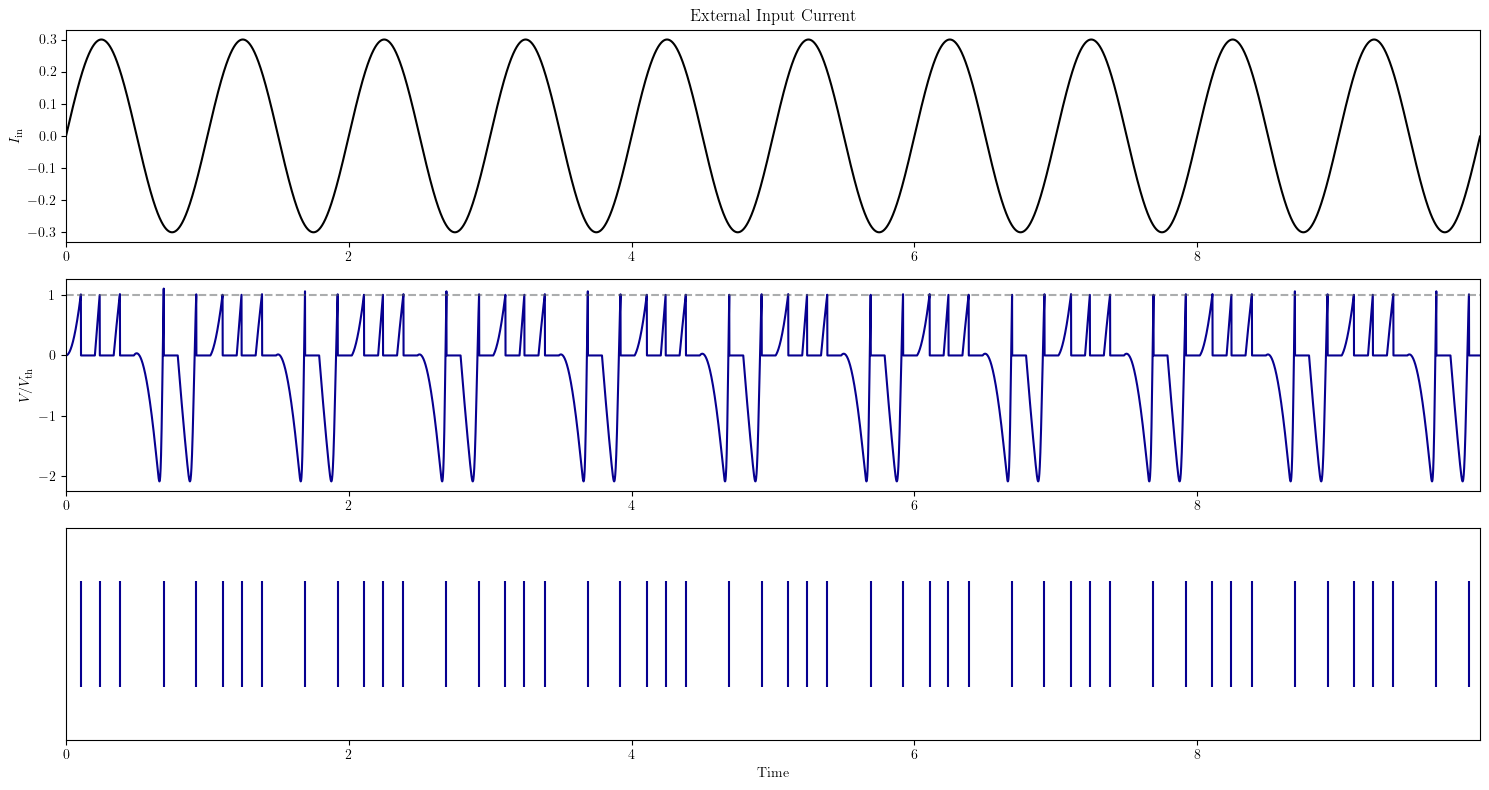

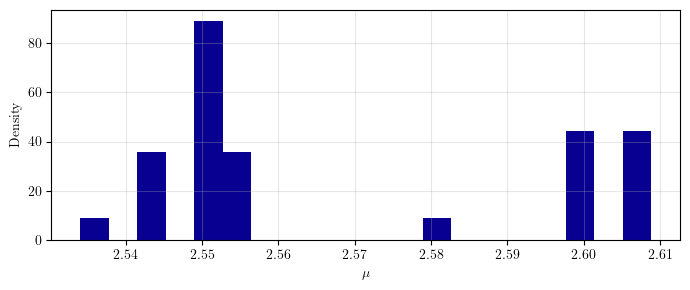

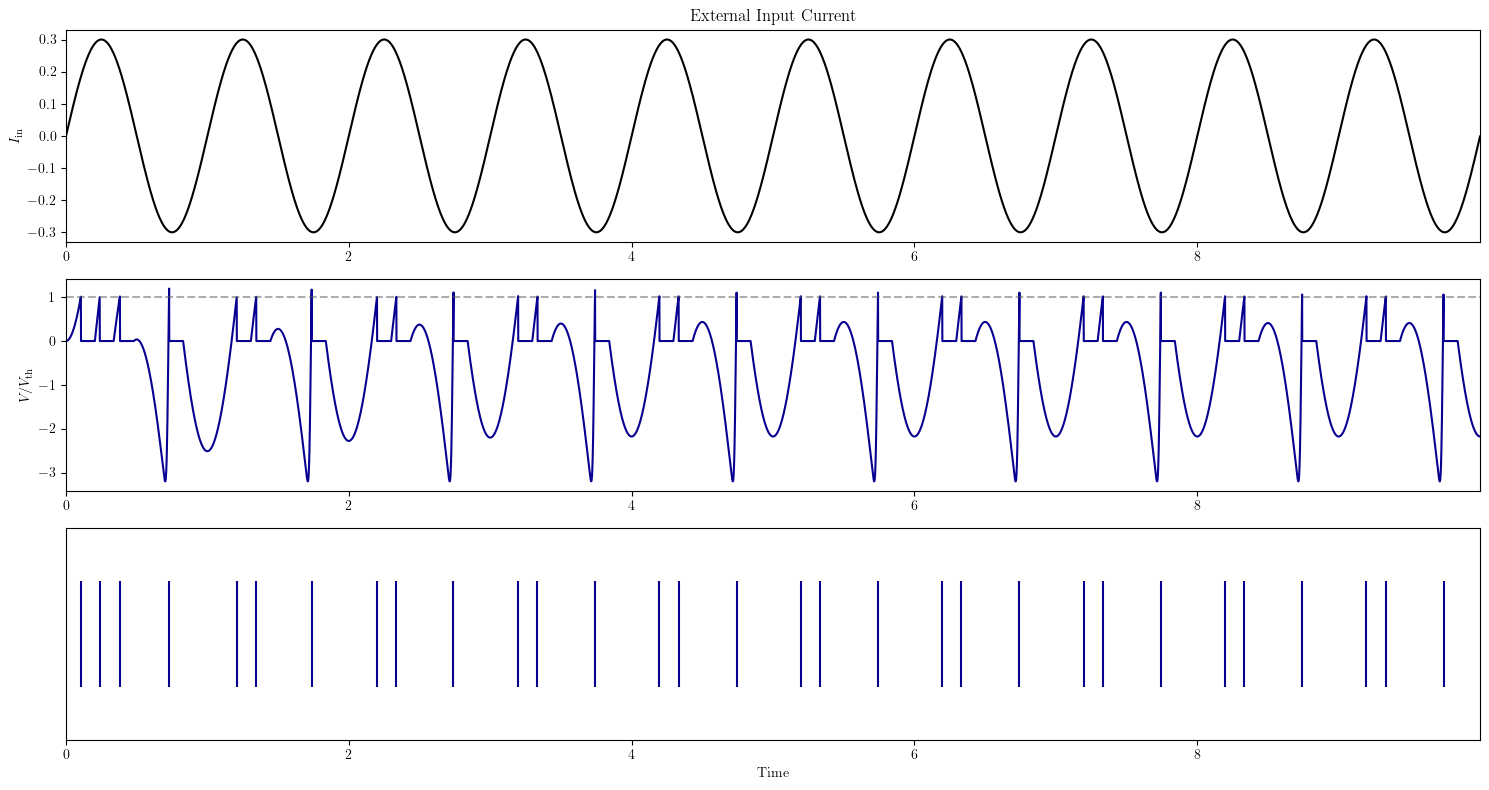

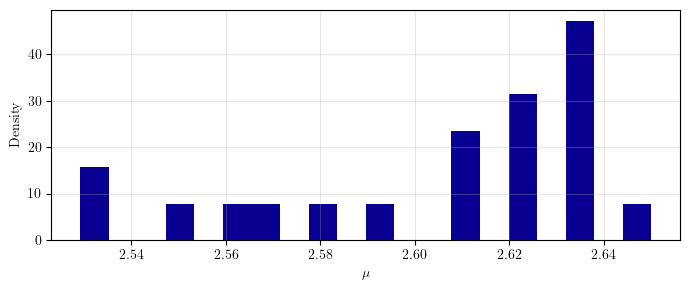

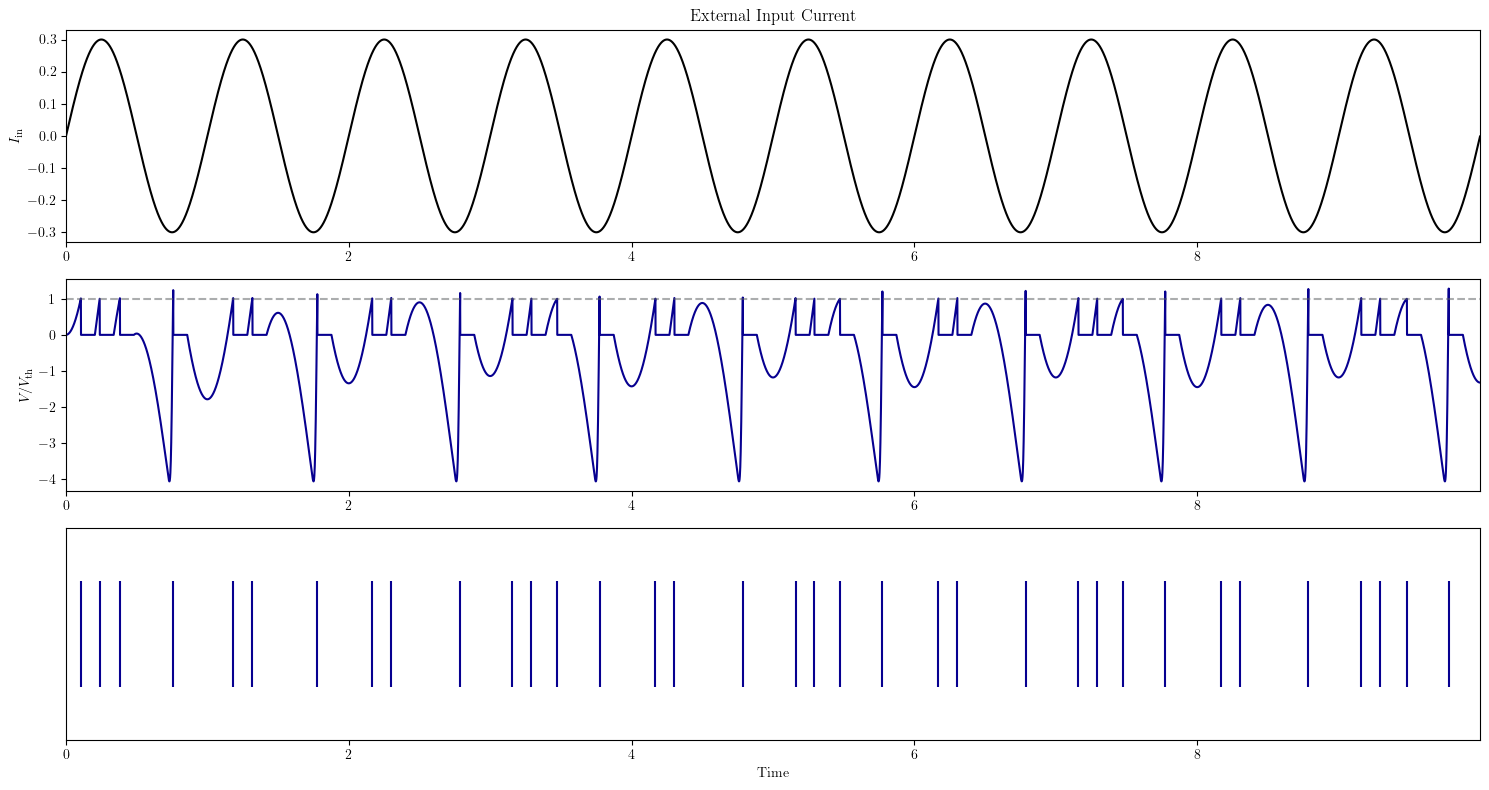

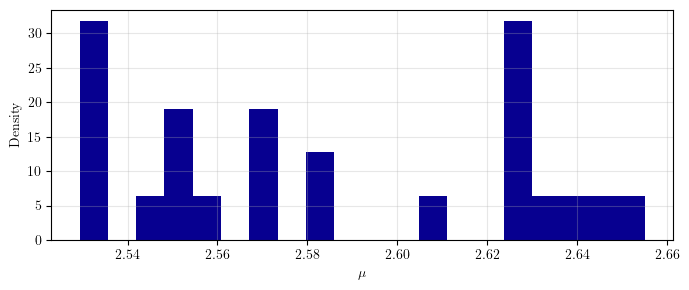

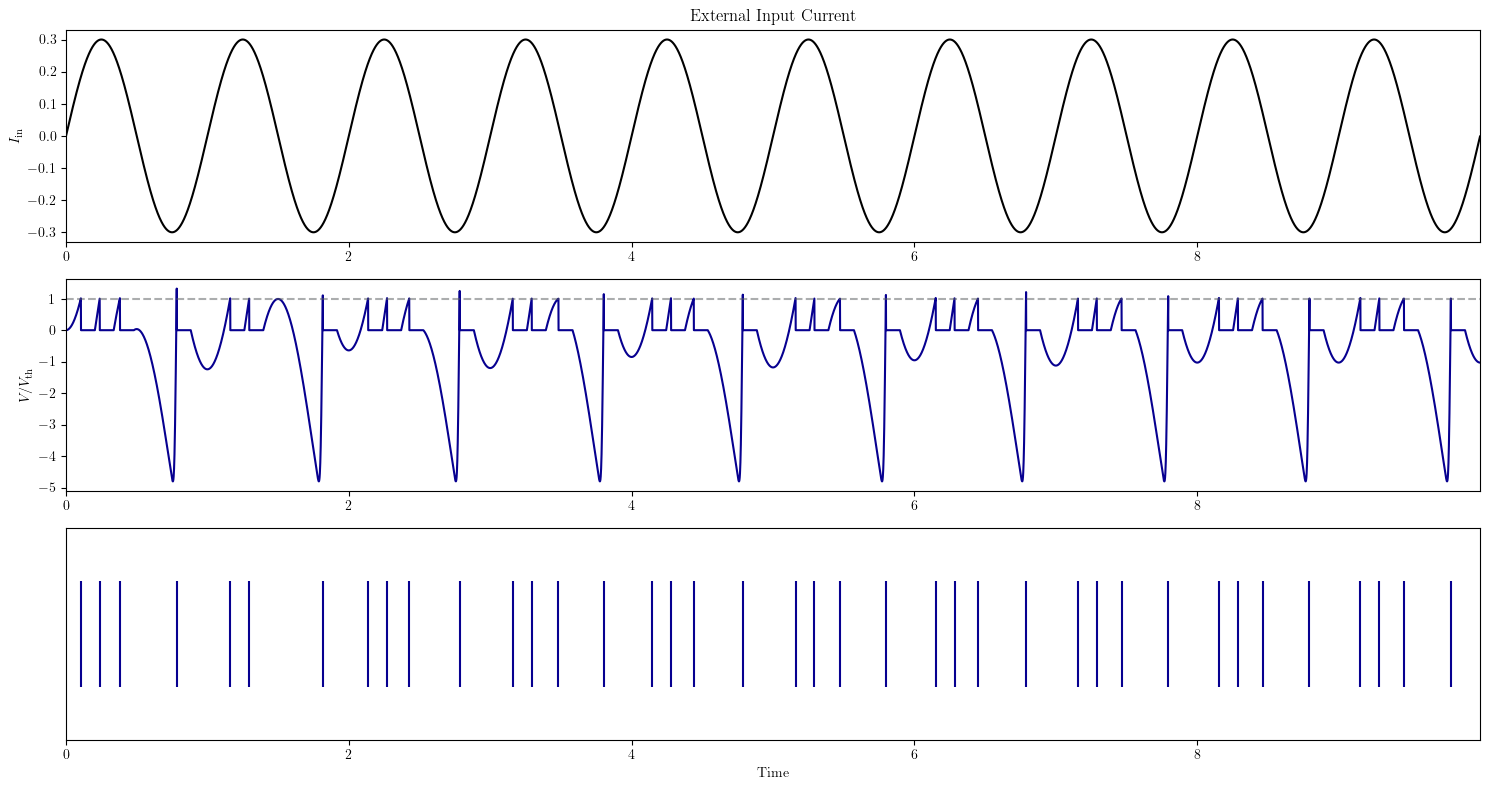

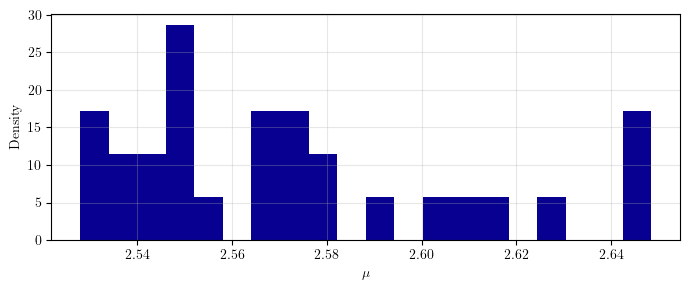

In [3]:
N_values = [20, 40, 60, 80]

# storage
nA_values = []          # spike count
mu_max_values = []      # maximum mu value
mu_max_sum_values = []  # number of spikes with amplitude close to the maximum
mu_mean_values = []     # mean mu value

for N in N_values:
    nA, mu_max, mu_max_sum, mu_mean = run_flock_space_analysis(N)
    nA_values.append(nA)
    mu_max_values.append(mu_max)
    mu_max_sum_values.append(mu_max_sum)
    mu_mean_values.append(mu_mean)

df = pd.DataFrame({"N": N_values, "spike_count": nA_values, "mu_max": mu_max_values, "mu_max_sum": mu_max_sum_values, "mu_mean": mu_mean_values})
df.to_csv(RESULTS_DIR / "flock_space.csv", index=False)

In [4]:
df["max/N"]=round(df["mu_max"]/df["N"], 2)
df["mean/N"]=round(df["mu_mean"]/df["N"], 2)
df

,N,spike_count,mu_max,mu_max_sum,mu_mean,max/N,mean/N
0,20,50,16.170135,20,7.999194,0.81,0.40
1,40,31,34.837726,10,12.989818,0.87,0.32
2,60,35,53.790570,10,17.192788,0.90,0.29
3,80,39,72.888011,10,20.587891,0.91,0.26


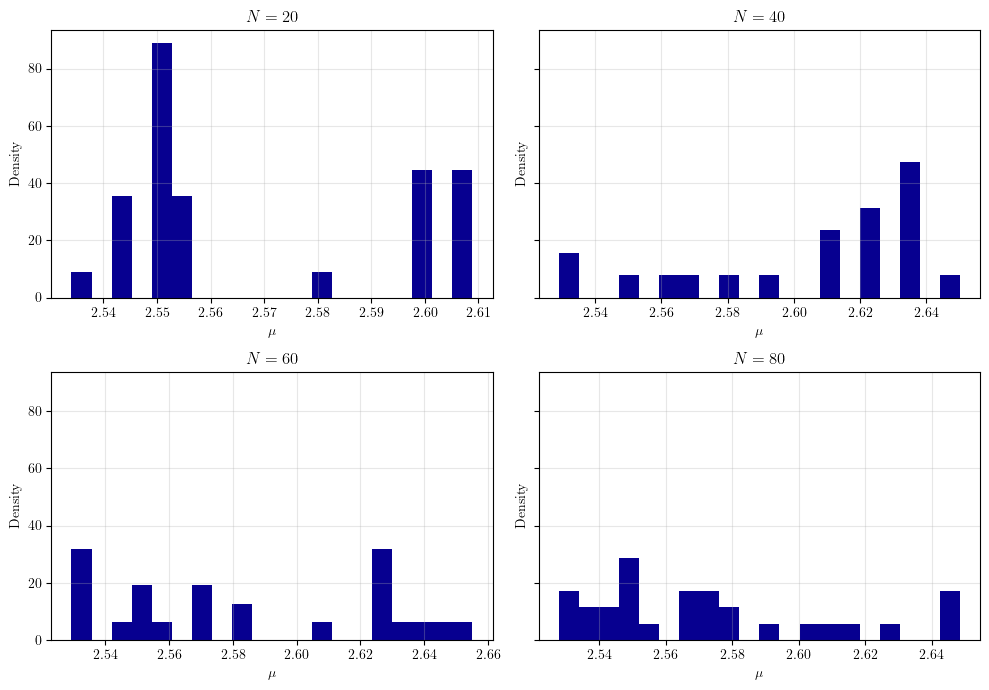

In [2]:
mu_distribution_N20_df = pd.read_csv(RESULTS_DIR / "mu_distribution_N20.csv")
mu_distribution_N40_df = pd.read_csv(RESULTS_DIR / "mu_distribution_N40.csv")
mu_distribution_N60_df = pd.read_csv(RESULTS_DIR / "mu_distribution_N60.csv")
mu_distribution_N80_df = pd.read_csv(RESULTS_DIR / "mu_distribution_N80.csv")

fig = plot.mu_distribution_panel(mu_distribution_N20_df["muA"], mu_distribution_N40_df["muA"], mu_distribution_N60_df["muA"], mu_distribution_N80_df["muA"])
fig.savefig(FIG_DIR / "mu_distribution_panel.pdf", bbox_inches="tight")

# Negative current

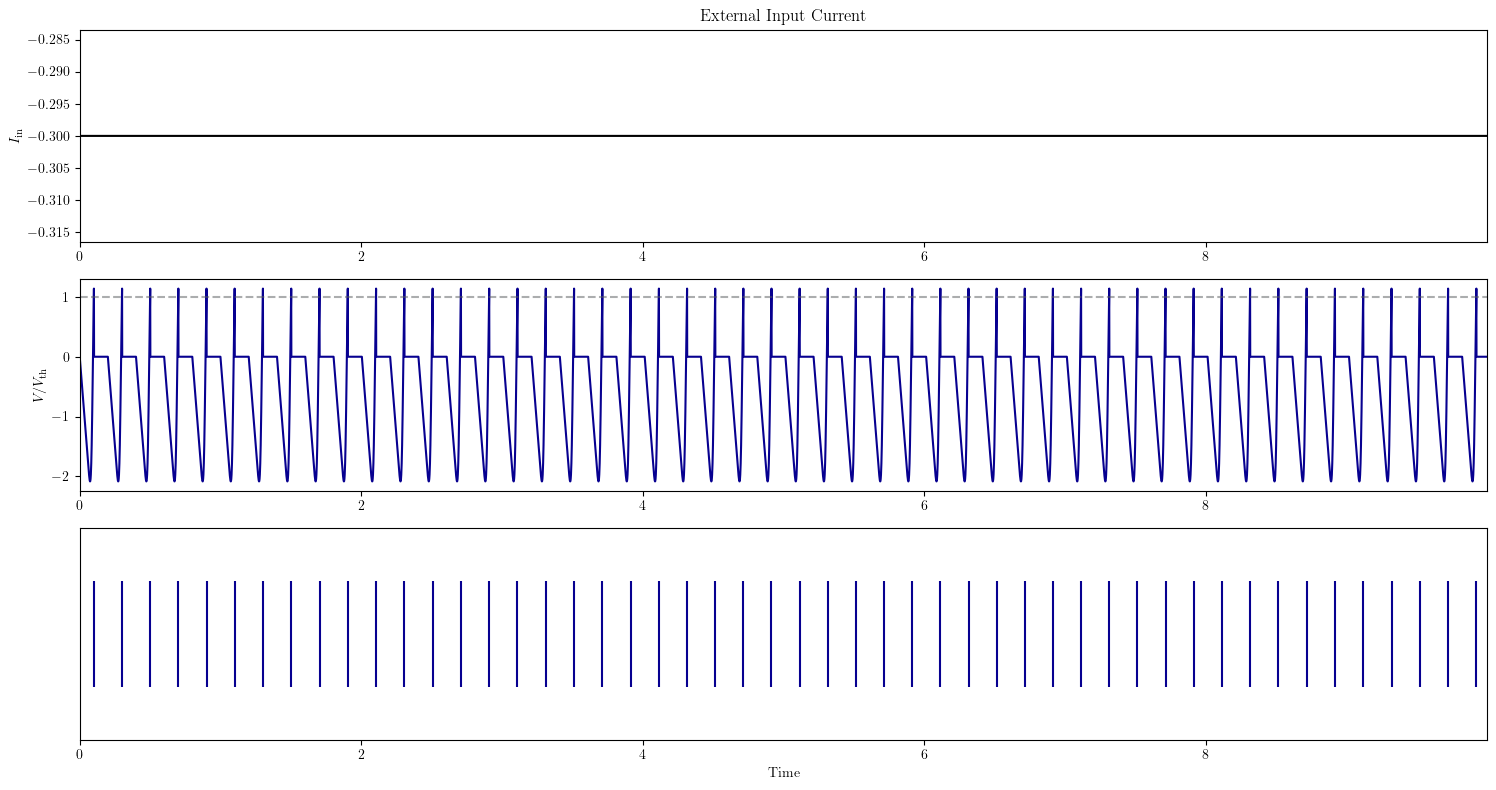

In [6]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0, tau_syn=0)
synapse_inh = Synapse(w=0, tau_syn=0)

input_current = constant_current(T=T, T_in=T, I0=-0.3)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.A_response(simulation_data)
fig.savefig(FIG_DIR / "negative_current.pdf", bbox_inches="tight")